# Notebook 16: Backtest Engine & Trade Construction

## Overview
Execution engine, translating the theoretical spread dynamics modeled in earlier notebooks into a realized equity curve. It simulates a systematic trading environment where the high-conviction signals—derived from the Kalman filter, Ornstein-Uhlenbeck mean reversion probabilities and HMM regime gates—are subjected to real-world trading mechanics and market frictions.

## Core Objectives
1. **Signal Ingestion:** Load the strict entry and exit signals generated in Notebook 15 for the USD-EUR 5Y spread.
2. **Target Position Mapping:** Convert boolean signal flags (`long_signal`, `short_signal`, `exit_signal`) into directional position targets (+1 for long, -1 for short, 0 for flat).
3. **Execution & Frictions:** Apply a standardized transaction cost model (10 bps roundtrip) to account for bid-ask spreads and slippage, ensuring the backtest reflects realistic net-of-fee performance.
4. **Trade Bookkeeping:** Utilize a state-machine engine to step through the time series, track open positions, calculate realized PnL upon exit, and log the holding period (in days) for every completed trade.
5. **Data Export:** Generate and save a comprehensive trade ledger (`trades.csv`) and cumulative PnL timeline (`equity_curve.csv`) to feed directly into the risk and performance evaluation in Notebook 17.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

def find_repo_root(start=None):
    if start is None:
        start = Path.cwd().resolve()
    for path in [start] + list(start.parents):
        if (path / "src").exists():
            return path
    raise FileNotFoundError("Could not locate repo root.")

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest.trade_builder import add_positions_to_signals
from src.backtest.engine import run_backtest

In [2]:
PAIR_ID = "JPY-AUD 5Y"
signals_path = ROOT / "results" / "signals" / f"{PAIR_ID}_signals.parquet" 
signals = pd.read_parquet(signals_path)
print(f"Loaded signals for {PAIR_ID}")

signals = add_positions_to_signals(signals)

print("Target positions generated:")
print(signals["target_position"].value_counts())

Loaded signals for JPY-AUD 5Y
Target positions generated:
target_position
 0    4376
-1     129
 1      95
Name: count, dtype: int64


In [3]:
# Run with standard costs (Net)
trades_net, equity_net = run_backtest(signals, cost_bps_per_leg=5.0)

# Run with no costs (Gross) to see pure statistical edge
trades_gross, equity_gross = run_backtest(signals, cost_bps_per_leg=0.0)

# Convert Yield PnL to compounded $1 growth
# This treats the yield PnL (e.g., 0.02) as a 2% return on allocated capital for that trade.
equity_net["growth_1usd"] = (1 + equity_net["daily_pnl"]).cumprod()
equity_gross["growth_1usd"] = (1 + equity_gross["daily_pnl"]).cumprod()

if not trades_net.empty:
    display_cols = ["entry_time", "exit_time", "direction", "entry_spread", "exit_spread", "pnl", "holding_days"]
    display(trades_net[display_cols].head(5))
    print(f"Total completed trades: {len(trades_net)}")

,entry_time,exit_time,direction,entry_spread,exit_spread,pnl,holding_days
0,2006-05-24,2006-05-25,1,0.091457,0.130980,0.038522,1
1,2006-06-12,2006-07-04,1,0.059102,0.166912,0.106810,22
2,2007-01-22,2007-02-05,1,-0.128971,-0.031937,0.096034,14
3,2007-05-31,2007-06-06,-1,0.086826,0.136479,-0.050653,6
4,2007-06-12,2007-07-02,-1,0.173843,0.101264,0.071579,20


Total completed trades: 57


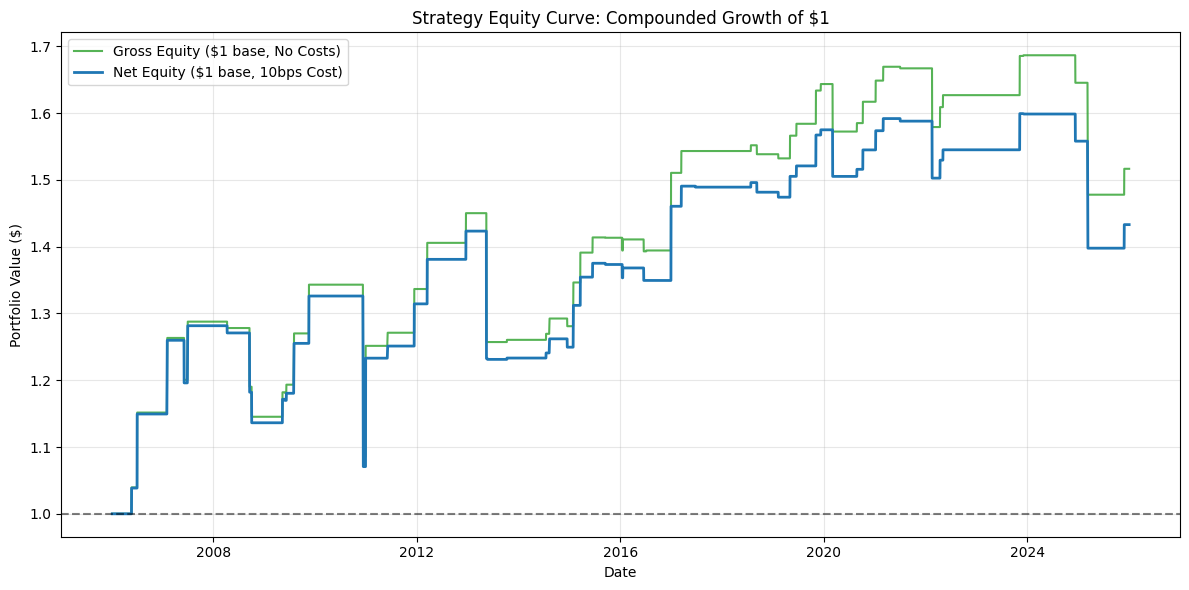

In [4]:
plt.figure(figsize=(12, 6))

# Plot Gross (No Costs)
plt.plot(equity_gross.index, equity_gross["growth_1usd"], 
         label="Gross Equity ($1 base, No Costs)", 
         color='#2ca02c', linewidth=1.5, alpha=0.8)

# Plot Net (With Costs)
plt.plot(equity_net.index, equity_net["growth_1usd"], 
         label="Net Equity ($1 base, 10bps Cost)", 
         color='#1f77b4', linewidth=2.0)

plt.title("Strategy Equity Curve: Compounded Growth of $1")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.grid(True, alpha=0.3)
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [5]:
out_dir = ROOT / "results" / "backtest"
out_dir.mkdir(parents=True, exist_ok=True)

# Exporting with PAIR_ID so you don't overwrite previous tests
trades_path = out_dir / f"{PAIR_ID}_trades.csv"
equity_path = out_dir / f"{PAIR_ID}_equity_curve.csv"

trades_net.to_csv(trades_path, index=False)
equity_net.to_csv(equity_path, index=True)

print(f"Data ready for Strategy Evaluation:")
print(f" ↳ {trades_path}")
print(f" ↳ {equity_path}")

Data ready for Strategy Evaluation:
 ↳ C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526\results\backtest\JPY-AUD 5Y_trades.csv
 ↳ C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526\results\backtest\JPY-AUD 5Y_equity_curve.csv
